<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_2_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

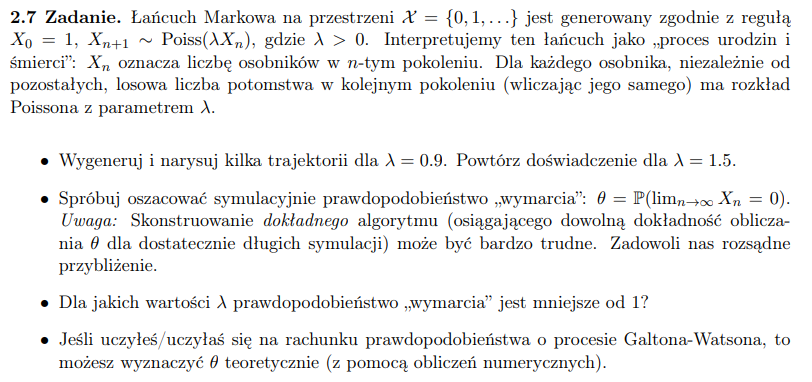

### Simulations
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def sampler(n=100, lam=0.9, x0=1):
  trajectory = [x0]
  for i in range(n):
    if trajectory[-1] < 1000000:
      pois = np.random.poisson(lam*trajectory[-1])
      trajectory.append(pois)
    else:
      trajectory.append(trajectory[-1])
  return trajectory

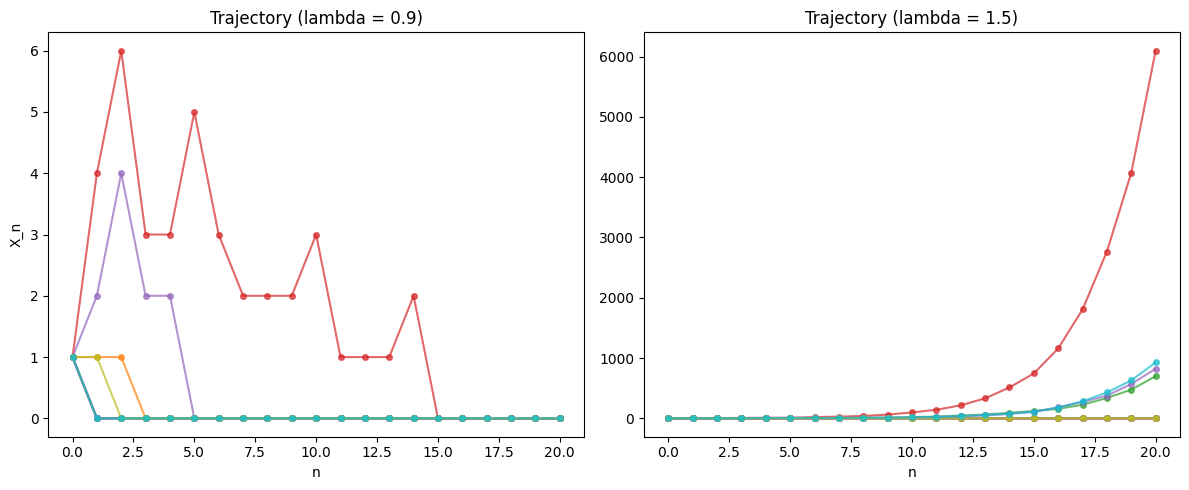

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


for _ in range(10):
    ax1.plot(sampler(n=20, lam=0.9), marker='o', markersize=4, alpha=0.7)
ax1.set_title("Trajectory (lambda = 0.9)")
ax1.set_xlabel("n")
ax1.set_ylabel("X_n")

for _ in range(10):
    ax2.plot(sampler(n=20, lam=1.5), marker='o', markersize=4, alpha=0.7)
ax2.set_title("Trajectory (lambda = 1.5)")
ax2.set_xlabel("n")

plt.tight_layout()
plt.show()

In [19]:
def extinction_function(lam=0.9, n_simulations=10000, max_steps=500):
  extinction_count = 0
  for i in range(n_simulations):
    trajectory = sampler(n=max_steps, lam=lam)
    if trajectory[-1] == 0:
      extinction_count += 1
  return extinction_count / n_simulations

In [20]:
extinction_prob = extinction_function(lam=0.9)
print("Extinction probability (lambda=0.9):", extinction_prob)

Extinction probability (lambda=0.9): 1.0


In [21]:
extinction_prob = extinction_function(lam=1.5)
print("Extinction probability (lambda=1.5):", extinction_prob)

Extinction probability (lambda=1.5): 0.4155


In [22]:
lambdas = [0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
results = []

for l in lambdas:
  extinction_prob = extinction_function(lam=l)
  print(f"Extinction probability (lambda={l}):", extinction_prob)
  results.append(extinction_prob)

Extinction probability (lambda=0.7): 1.0
Extinction probability (lambda=0.8): 1.0
Extinction probability (lambda=0.9): 1.0
Extinction probability (lambda=1): 0.9955
Extinction probability (lambda=1.1): 0.8192
Extinction probability (lambda=1.2): 0.6932
Extinction probability (lambda=1.3): 0.5823
Extinction probability (lambda=1.4): 0.4931
Extinction probability (lambda=1.5): 0.4138


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_7192/1609508605.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Extinction probability ($\\theta$) vs $\lambda$', fontsize=14, pad=15)
/tmp/ipykernel_7192/1609508605.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(f'$\lambda$', fontsize=12)


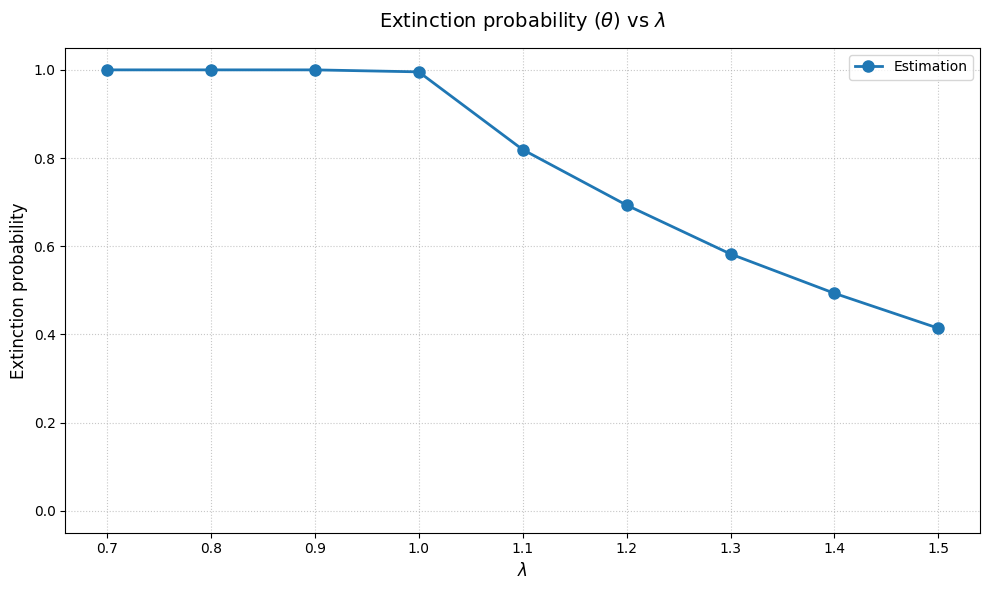

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(lambdas, results, marker='o', linestyle='-', color='#1f77b4',
         linewidth=2, markersize=8, label='Estimation')

plt.title('Extinction probability ($\\theta$) vs $\lambda$', fontsize=14, pad=15)
plt.xlabel(f'$\lambda$', fontsize=12)
plt.ylabel('Extinction probability', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()